<a href="https://colab.research.google.com/github/GeraldL19/Final-Year-Project-2024/blob/main/Supervisor_meeting_23_10_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Sentiment analysis on ESG news for DAX companies.
Trial 16/10/2023

Using the ESG news DAX company dataset from SwissText 'Detecting greenwashing signals through a comparison of ESG reports and public media'.
https://www.swisstext.org/shared-task-1-detecting-greenwashing-signals-through-a-comparison-of-esg-reports-and-public-media/

**Unalabeled datasets:**
*   Could manualy label 500 articles (5% of total datatets) to train model.
*   Could train semi-supervised models with 500 labeled articles.
*   Use unsupervised learning model?
*   Swisstext advised to use sentence token to train model for more graularity. Could label 500 sentences for training and 500 articles for testing?
*   Could reduce the datesets to only articles related to Environmental issues. This would reduce the datasets to 4800 rows. In this scenario 500 articles would represente 10% of total datatset.

**Issues:**

*   Financial setting means need for very accuracy. Unsupervised might not be adecquate.
*   500 labeled articles might not be enought to train a model properly.

**Models that could be used:**
*   Naïve Bayes
*   VADer

Transformers based:
*   FinBERT
*   finbert-esg / ESG-BERT
*   DistilRoBERTa-finetuned-financial-news

**Final product:**
*   The selection of the best performing model.
*   The final sentiment could be compared to freely available scores from yahoofinance or sustainalytics.
*   A dashboard with ESG sentiment for each company company.
*   Possibly displaying which topics are most talked about for each company, related to ESG.

*   This would not be use as prediction for stocks but as a tool to help ESG scorers and investors quickly get an idea of the public opinion about companies ESg commitment. Helping investors selecting companies that align best towards issues such as net zero.

**Potential other projects**
*   Financial news/tweets sentiment analysis
*   Movie recommendation using machine learning



In [ ]:
!pip install vaderSentiment
import pandas as pd
import numpy as np
import matplotlib as plt
import re
import random

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import RegexpTokenizer
# nltk imports
from nltk.tokenize import word_tokenize  # tokenize the text == the text is splitted into words in list
from nltk.corpus import stopwords  # this contain common stop words that has no effect in analysis
from nltk.stem import WordNetLemmatizer  # Lemmatization is the process of grouping together the different inflected forms of a word so they can be analyzed as a single item
from nltk.tokenize import sent_tokenize, word_tokenize

# download nltk corpus (first time only)
import nltk

nltk.download('all')



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping grammars/basque_grammars.zip.
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    | Downloading package biocreative_ppi to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   U

True

In [ ]:
! pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 64.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 33.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 94.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 30.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path

from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

import numpy as np
from scipy.special import softmax
import csv
import urllib.request

In [ ]:
df = pd.read_csv('esg_documents_for_dax_companies.csv', delimiter = '|', index_col = 0)

In [ ]:
# Sorting dataframe by companies in alphabetical order
df = df.sort_values('company', ascending=True)
# Now we can properly reset the index
df = df.reset_index(drop=True)
df


,company,content,datatype,date,domain,esg_topics,internal,symbol,title,url
0,Adidas AG,"Since March 2021, Puerto Rican musician Benito...",general,2022-04-21,teenvogue,['Privacy'],0,ADS,Bad Bunny Teased a New Pair of His Own Adidas ...,https://www.teenvogue.com/story/bad-bunny-baby...
1,Adidas AG,"Hi, what are you looking for? By Published Fut...",tech,2021-03-23,digitaljournal,"['Social', 'GenderDiversity']",0,ADS,Adidas will sell 3D-printed shoes,https://www.digitaljournal.com/business/adidas...
2,Adidas AG,"Hi, what are you looking for? By Published Chr...",tech,2021-03-26,digitaljournal,"['Governance', 'Meat', 'GenderDiversity', 'Rus...",0,ADS,Christine Lagarde continues to break glass cei...,https://www.digitaljournal.com/world/christine...
3,Adidas AG,"We may not be able to travel, and spring may b...",general,2021-03-12,theguardian,"['GenderDiversity', 'Social']",0,ADS,Alpine glamour snowballs despite lack of off-p...,https://www.theguardian.com/fashion/2021/mar/1...
4,Adidas AG,"TEL AVIV, Israel — June 18, 2021 — adidas and ...",general,2021-06-18,textileworld,"['Recycling', 'GenderDiversity']",0,ADS,"Delta Galil, adidas Announce License Agreement...",https://www.textileworld.com/textile-world/kni...
...,...,...,...,...,...,...,...,...,...,...
11543,Zalando SE,"To reset your pass, please enter your email be...",tech,2021-07-12,pocketgamer,"['CustomerService', 'Meat', 'HumanCapital', 'T...",0,ZAL,Pocket Gamer Connects Digital # 7,https://www.pocketgamer.biz/events/1636/pocket...
11544,Zalando SE,Lo esencial: Materias primas: correlaciones e...,business,2022-07-05,marketscreener,['WasteManagement'],0,ZAL,"Índices: ni Value ni Growth, ¡defensivos!",https://es.marketscreener.com/noticias/ultimas...
11545,Zalando SE,A look at the evolution of the fashion industr...,thinktank,2021-05-11,cbinsights,"['CustomerService', 'Recruiting', 'Sustainable...",0,ZAL,The Future of Fashion: Technology & the Industry,https://www.cbinsights.com/research/fashion-te...
11546,Zalando SE,The information you requested is not available...,business,2022-06-02,bnnbloomberg,"['RussianFederation', 'HumanRights', 'Boycott']",0,ZAL,Germany Risks Reprising Sick Man Status on Rus...,https://www.bnnbloomberg.ca/germany-risks-repr...


# Filtering the datasets to only Enivornment related topics to reduce size compared to labeled dataset.

In [ ]:
#Getting rid of brackets
df['esg_topics'] = df['esg_topics'].str.replace("[", "")
df['esg_topics'] = df['esg_topics'].str.replace("]", "")
#Select only Environment related topic
tags_to_check = ['Environment', 'CarbonDioxide', 'RenewableEnergy', 'GHGEmission', 'LowCarbon',
                 'NaturalGas', 'ClimateChange', 'FossilFuels', 'Recycling', 'EnergyEfficiency', 'Pollution']

filtered_df = df[df['esg_topics'].apply(lambda x: any(tag in x for tag in tags_to_check))]

filtered_df = filtered_df[filtered_df['internal'] == 0]

columns_to_drop = ['date', 'internal', 'title', 'url']
filtered_df.drop(columns=columns_to_drop, inplace=True)

<ipython-input-5-5e63cb0e7439>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['esg_topics'] = df['esg_topics'].str.replace("[", "")
<ipython-input-5-5e63cb0e7439>:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['esg_topics'] = df['esg_topics'].str.replace("]", "")


In [ ]:
filtered_df

,company,content,datatype,domain,esg_topics,symbol
4,Adidas AG,"TEL AVIV, Israel — June 18, 2021 — adidas and ...",general,textileworld,"'Recycling', 'GenderDiversity'",ADS
5,Adidas AG,"ESPOO, Finland — July 5, 2021 — Circular fashi...",general,textileworld,"'Recycling', 'SustainableMaterials', 'Sustaina...",ADS
6,Adidas AG,"JYVÄSKYLÄ, Finland — September 8, 2021 — Londo...",general,textileworld,"'CarbonDioxide', 'SustainableMaterials'",ADS
15,Adidas AG,ADVERTISEMENT As Trey Parker and Matt Stone c...,general,sneakernews,'Recycling',ADS
21,Adidas AG,The Transform Technology Summits start October...,tech,venturebeat,"'HumanCapital', 'Cybersecurity', 'DataSecurity...",ADS
...,...,...,...,...,...,...
11540,Zalando SE,"To reset your pass, please enter your email be...",tech,pocketgamer,"'Privacy', 'Cybersecurity', 'CustomerService',...",ZAL
11541,Zalando SE,"To reset your pass, please enter your email be...",tech,pocketgamer,"'Privacy', 'CustomerService', 'HumanCapital', ...",ZAL
11543,Zalando SE,"To reset your pass, please enter your email be...",tech,pocketgamer,"'CustomerService', 'Meat', 'HumanCapital', 'Tr...",ZAL
11545,Zalando SE,A look at the evolution of the fashion industr...,thinktank,cbinsights,"'CustomerService', 'Recruiting', 'SustainableM...",ZAL


In [ ]:
df_sentences = filtered_df[['company','content']].copy()

#df_sentences_sample = df_sentences.sample(n = 20)
#df_sentences_sample = df_sentences_sample.reset_index(drop = True)
#df_sentences_sample


#Removing all non-word and lemmatize(reduce words to their basic form).

Taken from Claire Bussat answer to Swisstext problem.
https://colab.research.google.com/drive/1ifnmsYgi0POHQLXQ3xcX7-7cXfec4nED#scrollTo=v5ZI04Vyg3C0

In [ ]:
#Taken from Claire Bussat answer to Swisstext problem
nltk.download('wordnet')

# Initialize a lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Check if the input is a string
    if not isinstance(text, str):
        return ''

    # First we'll use regular expressions to strip out web site adresses
    text = re.sub(r'http[a-zA-Z0-9\&\?\=\?\/\:\.]+\b', ' ', text)
    text = re.sub(r'\<[^\<\>]+\>', ' ', text)
    # Next, let's clear out all punctuation and replace it with whitespace
    text = re.sub(r'\W+', ' ', text)
    # And clear out numbers
    text = re.sub(r'[0-9]+', ' ', text)
    # And then lowercase
    text = text.lower()


    # Next, let's split on whitespace and then lemmatize each token
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(x) for x in tokens]
    text = " ".join(tokens)

    return text


filtered_df['content_clean'] = filtered_df['content'].map(clean_text)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Tokenization**

In [ ]:
# Download necessary nltk data
nltk.download('stopwords')
nltk.download('punkt')

stop_words_nltk = stopwords.words('english')

# Create a function to remove stopwords and tokenize
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    tokens = nltk.word_tokenize(text)
    filtered_tokens= [word for word in tokens if word not in stop_words]
    filtered_text = ' '.join(filtered_tokens)
    return filtered_text


filtered_df['content_clean'] = filtered_df['content_clean'].astype(str)
filtered_df.dropna(subset=['content_clean'], inplace=True)


filtered_df['content_tokens'] = filtered_df['content_clean'].apply(remove_stopwords)

filtered_df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,company,content,datatype,domain,esg_topics,symbol,content_clean,content_tokens
4,Adidas AG,"TEL AVIV, Israel — June 18, 2021 — adidas and ...",general,textileworld,"'Recycling', 'GenderDiversity'",ADS,tel aviv israel june adidas and delta galil in...,tel aviv israel june adidas delta galil indust...
5,Adidas AG,"ESPOO, Finland — July 5, 2021 — Circular fashi...",general,textileworld,"'Recycling', 'SustainableMaterials', 'Sustaina...",ADS,espoo finland july circular fashion and textil...,espoo finland july circular fashion textile te...
6,Adidas AG,"JYVÄSKYLÄ, Finland — September 8, 2021 — Londo...",general,textileworld,"'CarbonDioxide', 'SustainableMaterials'",ADS,jyväskylä finland september london based desig...,jyväskylä finland september london based desig...
15,Adidas AG,ADVERTISEMENT As Trey Parker and Matt Stone c...,general,sneakernews,'Recycling',ADS,advertisement a trey parker and matt stone con...,advertisement trey parker matt stone continue ...
21,Adidas AG,The Transform Technology Summits start October...,tech,venturebeat,"'HumanCapital', 'Cybersecurity', 'DataSecurity...",ADS,the transform technology summit start october ...,transform technology summit start october th l...


In [ ]:
#Extracting random sample of 20 articles.
df_sample = filtered_df[['company','content', 'content_clean', 'content_tokens']].copy()

df_sample = df_sample.sample(n = 20)
df_sample = df_sample.reset_index(drop = True)
df_sample

,company,content,content_clean,content_tokens
0,Airbus SE,"Hi, what are you looking for? By Published Egy...",hi what are you looking for by published egypt...,hi looking published egypt enlisted submersibl...
1,BMW,"STAMFORD, Conn. — January 14, 2016 — Hexcel is...",stamford conn january hexcel is pleased to hav...,stamford conn january hexcel pleased innovativ...
2,Vonovia,Vonovia's acquisition of Deutsche Wohnen and H...,vonovia s acquisition of deutsche wohnen and h...,vonovia acquisition deutsche wohnen heimstaden...
3,SAP,The global field service management ( FSM) mar...,the global field service management fsm market...,global field service management fsm market siz...
4,Symrise AG,Looking for More? Our expert team of researche...,looking for more our expert team of researcher...,looking expert team researcher create market a...
5,E ONSE,"European equities edged higher on Wednesday, b...",european equity edged higher on wednesday but ...,european equity edged higher wednesday trader ...
6,AkzoNobelNV,Italian energy giant Eni SpA and German indust...,italian energy giant eni spa and german indust...,italian energy giant eni spa german industrial...
7,Siemens Healthineers AG,"Atos, Siemens and Morocco's National Office of...",atos siemens and morocco s national office of ...,atos siemens morocco national office electrici...
8,Infineon Technologies AG,In recent years members of parliament from par...,in recent year member of parliament from party...,recent year member parliament party across pol...
9,Muenchener Rueckversicherungs Gesellschaft AGi...,Rising ransomware attacks and higher payout de...,rising ransomware attack and higher payout dem...,rising ransomware attack higher payout demand ...


In [ ]:
#Create and export a csv file from google collab
from google.colab import files
df_sample.to_csv('trial.csv')
files.download('trial.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_trial = pd.read_csv('trial.csv', index_col = 0)
df_trial

,company,content,content_clean,content_tokens
0,Airbus SE,"Hi, what are you looking for? By Published Egy...",hi what are you looking for by published egypt...,hi looking published egypt enlisted submersibl...
1,BMW,"STAMFORD, Conn. — January 14, 2016 — Hexcel is...",stamford conn january hexcel is pleased to hav...,stamford conn january hexcel pleased innovativ...
2,Vonovia,Vonovia's acquisition of Deutsche Wohnen and H...,vonovia s acquisition of deutsche wohnen and h...,vonovia acquisition deutsche wohnen heimstaden...
3,SAP,The global field service management ( FSM) mar...,the global field service management fsm market...,global field service management fsm market siz...
4,Symrise AG,Looking for More? Our expert team of researche...,looking for more our expert team of researcher...,looking expert team researcher create market a...
5,E ONSE,"European equities edged higher on Wednesday, b...",european equity edged higher on wednesday but ...,european equity edged higher wednesday trader ...
6,AkzoNobelNV,Italian energy giant Eni SpA and German indust...,italian energy giant eni spa and german indust...,italian energy giant eni spa german industrial...
7,Siemens Healthineers AG,"Atos, Siemens and Morocco's National Office of...",atos siemens and morocco s national office of ...,atos siemens morocco national office electrici...
8,Infineon Technologies AG,In recent years members of parliament from par...,in recent year member of parliament from party...,recent year member parliament party across pol...
9,Muenchener Rueckversicherungs Gesellschaft AGi...,Rising ransomware attacks and higher payout de...,rising ransomware attack and higher payout dem...,rising ransomware attack higher payout demand ...


#VADer sentiment analyser - unsupervised

In [ ]:
analyser = SentimentIntensityAnalyzer()

In [ ]:
df_trial['VADer'] = df_trial['content_tokens'].apply(lambda Sentence: analyser.polarity_scores(Sentence)['compound'])
df_trial

,company,content,content_clean,content_tokens,VADer
0,Airbus SE,"Hi, what are you looking for? By Published Egy...",hi what are you looking for by published egypt...,hi looking published egypt enlisted submersibl...,-0.9976
1,BMW,"STAMFORD, Conn. — January 14, 2016 — Hexcel is...",stamford conn january hexcel is pleased to hav...,stamford conn january hexcel pleased innovativ...,0.9790
2,Vonovia,Vonovia's acquisition of Deutsche Wohnen and H...,vonovia s acquisition of deutsche wohnen and h...,vonovia acquisition deutsche wohnen heimstaden...,0.9808
3,SAP,The global field service management ( FSM) mar...,the global field service management fsm market...,global field service management fsm market siz...,0.9999
4,Symrise AG,Looking for More? Our expert team of researche...,looking for more our expert team of researcher...,looking expert team researcher create market a...,0.9949
5,E ONSE,"European equities edged higher on Wednesday, b...",european equity edged higher on wednesday but ...,european equity edged higher wednesday trader ...,0.9982
6,AkzoNobelNV,Italian energy giant Eni SpA and German indust...,italian energy giant eni spa and german indust...,italian energy giant eni spa german industrial...,0.9963
7,Siemens Healthineers AG,"Atos, Siemens and Morocco's National Office of...",atos siemens and morocco s national office of ...,atos siemens morocco national office electrici...,0.9994
8,Infineon Technologies AG,In recent years members of parliament from par...,in recent year member of parliament from party...,recent year member parliament party across pol...,-0.9738
9,Muenchener Rueckversicherungs Gesellschaft AGi...,Rising ransomware attacks and higher payout de...,rising ransomware attack and higher payout dem...,rising ransomware attack higher payout demand ...,-0.9963


In [ ]:
df_trial.iloc[16,4]

0.9825

In [ ]:
df_trial.iloc[16,1]

"Fossil fuels could be replaced by hydrogen, though, a versatile energy medium that in addition is able to be stored extremely well at low temperatures. `` Our idea was therefore to use solar modules to produce climate-neutral hydrogen on site during the Antarctic summer by splitting water into hydrogen and oxygen through electrolysis, '' says May, then a postdoc at the Helmholtz-Zentrum Berlin Institute for Solar Fuels. Rehfeld and May applied for funding from the Volkswagen Foundation to investigate whether hydrogen can be generated using sunlight even at sub-zero temperatures, and which method is best suited for this. Low temperatures can considerably reduce the efficiency of electrolysis, though cold actually increases the efficiency of most solar modules. May and his HZB colleague, Moritz Kölbach, have now empirically compared two different approaches: a conventional setup in which the photovoltaic module is thermally and physically separated from the electrolysis tank, and a newe

In [ ]:
def valuemaker(i):
  if i < -0.5:
    i = -1
  elif i > 0.5:
    i = 1
  else:
    i = 0
  return i

In [ ]:
df_trial['VADer'] = df_trial['VADer'].apply(valuemaker)
df_trial



,company,content,content_clean,content_tokens,VADer
0,Airbus SE,"Hi, what are you looking for? By Published Egy...",hi what are you looking for by published egypt...,hi looking published egypt enlisted submersibl...,-1
1,BMW,"STAMFORD, Conn. — January 14, 2016 — Hexcel is...",stamford conn january hexcel is pleased to hav...,stamford conn january hexcel pleased innovativ...,1
2,Vonovia,Vonovia's acquisition of Deutsche Wohnen and H...,vonovia s acquisition of deutsche wohnen and h...,vonovia acquisition deutsche wohnen heimstaden...,1
3,SAP,The global field service management ( FSM) mar...,the global field service management fsm market...,global field service management fsm market siz...,1
4,Symrise AG,Looking for More? Our expert team of researche...,looking for more our expert team of researcher...,looking expert team researcher create market a...,1
5,E ONSE,"European equities edged higher on Wednesday, b...",european equity edged higher on wednesday but ...,european equity edged higher wednesday trader ...,1
6,AkzoNobelNV,Italian energy giant Eni SpA and German indust...,italian energy giant eni spa and german indust...,italian energy giant eni spa german industrial...,1
7,Siemens Healthineers AG,"Atos, Siemens and Morocco's National Office of...",atos siemens and morocco s national office of ...,atos siemens morocco national office electrici...,1
8,Infineon Technologies AG,In recent years members of parliament from par...,in recent year member of parliament from party...,recent year member parliament party across pol...,-1
9,Muenchener Rueckversicherungs Gesellschaft AGi...,Rising ransomware attacks and higher payout de...,rising ransomware attack and higher payout dem...,rising ransomware attack higher payout demand ...,-1


<Axes: >

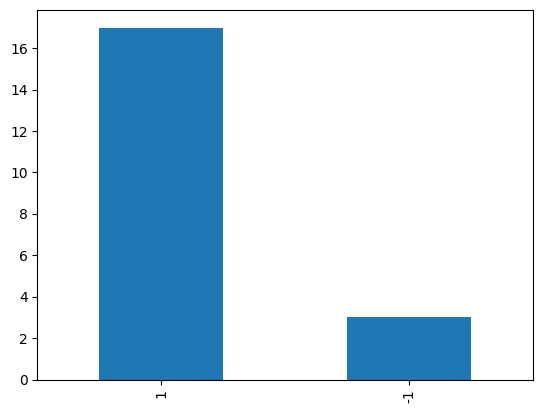

In [ ]:
df_trial.VADer.value_counts().plot.bar()

#Trying twitter-roberta

Again taken from Claire Bussat answer code.

In [ ]:
 # Load the pre-trained model and tokenizer
task = 'sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Download label mapping
labels = []
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
    labels = [row[1] for row in csvreader if len(row) > 1]

# Specify the number of rows to process
num_rows = 20

# Create a subset of the DataFrame with the desired number of rows
df_subset = df_trial.head(num_rows)

# Perform sentiment analysis on each preprocessed text
bert_sentiments = []
for text in df_trial['content_tokens'].head(num_rows):
    encoded_input = tokenizer(text, truncation=True, padding=True, max_length=128, return_tensors='pt')
    output = model(**encoded_input)
    scores = output.logits[0].detach().numpy()
    scores = softmax(scores)
    ranking = np.argsort(scores)
    ranking = ranking[::-1]
    sentiment_label = labels[ranking[0]]  # Assuming you want to retrieve the top-ranked sentiment label
    bert_sentiments.append(sentiment_label)

# Assign the generated sentiments to a new column in your DataFrame
df_trial['BERT'] = bert_sentiments

# Print the DataFrame with the generated sentiments
#print(df_subset[['sentences', 'Scores', 'generated_sentiment']])

In [ ]:
df_trial

,company,content,content_clean,content_tokens,VADer,BERT
0,Airbus SE,"Hi, what are you looking for? By Published Egy...",hi what are you looking for by published egypt...,hi looking published egypt enlisted submersibl...,-1,neutral
1,BMW,"STAMFORD, Conn. — January 14, 2016 — Hexcel is...",stamford conn january hexcel is pleased to hav...,stamford conn january hexcel pleased innovativ...,1,neutral
2,Vonovia,Vonovia's acquisition of Deutsche Wohnen and H...,vonovia s acquisition of deutsche wohnen and h...,vonovia acquisition deutsche wohnen heimstaden...,1,neutral
3,SAP,The global field service management ( FSM) mar...,the global field service management fsm market...,global field service management fsm market siz...,1,neutral
4,Symrise AG,Looking for More? Our expert team of researche...,looking for more our expert team of researcher...,looking expert team researcher create market a...,1,neutral
5,E ONSE,"European equities edged higher on Wednesday, b...",european equity edged higher on wednesday but ...,european equity edged higher wednesday trader ...,1,neutral
6,AkzoNobelNV,Italian energy giant Eni SpA and German indust...,italian energy giant eni spa and german indust...,italian energy giant eni spa german industrial...,1,positive
7,Siemens Healthineers AG,"Atos, Siemens and Morocco's National Office of...",atos siemens and morocco s national office of ...,atos siemens morocco national office electrici...,1,positive
8,Infineon Technologies AG,In recent years members of parliament from par...,in recent year member of parliament from party...,recent year member parliament party across pol...,-1,neutral
9,Muenchener Rueckversicherungs Gesellschaft AGi...,Rising ransomware attacks and higher payout de...,rising ransomware attack and higher payout dem...,rising ransomware attack higher payout demand ...,-1,neutral


<Axes: >

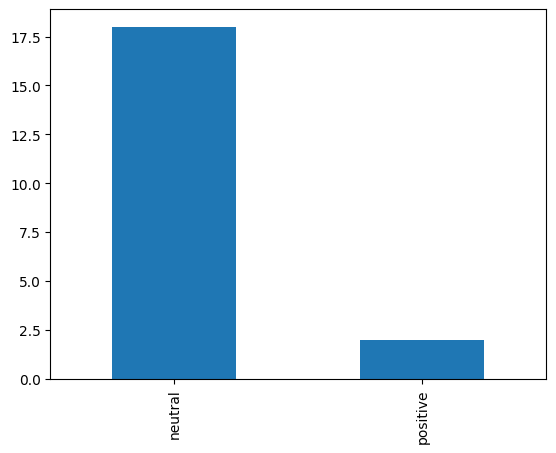

In [ ]:
df_trial.BERT.value_counts().plot.bar()

In [ ]:
# Get all tokenized content words
all_content = df_trial['content_tokens']
all_content

0     hi looking published egypt enlisted submersibl...
1     stamford conn january hexcel pleased innovativ...
2     vonovia acquisition deutsche wohnen heimstaden...
3     global field service management fsm market siz...
4     looking expert team researcher create market a...
5     european equity edged higher wednesday trader ...
6     italian energy giant eni spa german industrial...
7     atos siemens morocco national office electrici...
8     recent year member parliament party across pol...
9     rising ransomware attack higher payout demand ...
10    consumer metaverse exemplified immersive game ...
11    ofgem ha confirmed today august domestic dual ...
12    sporting brand adidas ha become latest company...
13    innovative mobility exciting trend future high...
14    join today leading executive online data summi...
15    sustainable aviation fuel commonly called saf ...
16    fossil fuel could replaced hydrogen though ver...
17    gsma declares commercial readiness gsma eb

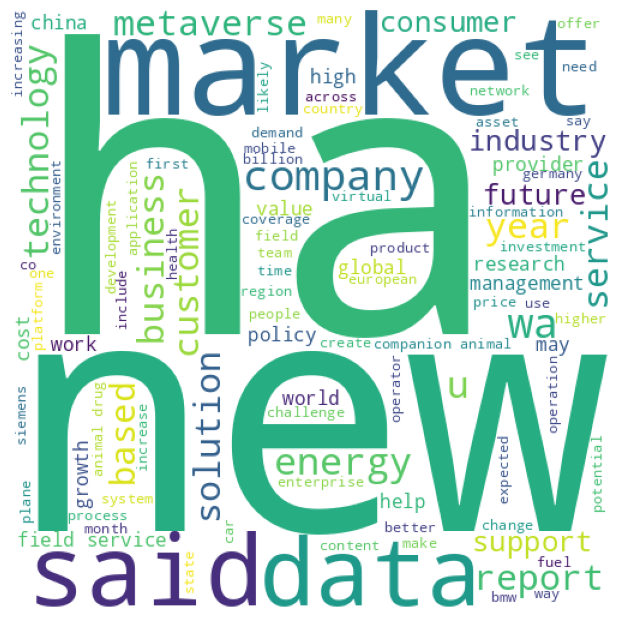

In [ ]:
#wordcloud
wordcloud = WordCloud(width = 500, height = 500,
                background_color ='white',
                min_font_size = 10).generate(all_content.str.cat())

# plot the WordCloud
plt.figure(figsize = (6, 6), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

#TF-IDF trial

In [ ]:
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.9, # Remove any words that appear in more than 90% of our documents
    min_df=5, # Remove words that appear in fewer than 5 document
    ngram_range=(1, 1), # Only extract unigrams
    stop_words='english', # Remove stopwords
    max_features=2500 # Grab the 2500 most common words (based on above constraints)
)
tfidf = tfidf_vectorizer.fit_transform(df_trial['content'])
ngrams = tfidf_vectorizer.get_feature_names_out()

In [ ]:
ngrams

array(['2020', '2021', '2022', '2023', '30', 'according', 'added',
       'addition', 'aims', 'analysis', 'announced', 'asset', 'assets',
       'available', 'based', 'better', 'billion', 'business', 'carbon',
       'challenges', 'change', 'com', 'come', 'companies', 'company',
       'compared', 'contact', 'content', 'continue', 'control', 'cost',
       'costs', 'create', 'critical', 'current', 'customer', 'data',
       'day', 'decision', 'demand', 'development', 'different', 'digital',
       'does', 'early', 'efficiency', 'efforts', 'emissions', 'end',
       'energy', 'ensure', 'environment', 'europe', 'european',
       'expected', 'far', 'february', 'firm', 'focus', 'focused',
       'forward', 'fuel', 'future', 'german', 'global', 'government',
       'group', 'growth', 'health', 'help', 'high', 'include',
       'including', 'increase', 'increased', 'increasing', 'industrial',
       'industry', 'information', 'intelligence', 'investment', 'just',
       'key', 'large', 'lea

#On sentence level for more granularity

In [ ]:
df_1 = df_trial

In [ ]:
# Tokenize in sentences
nltk.download('punkt')

# Tokenize the sentences in the 'content' column
def tokenize_sentences(content):
    try:
        return sent_tokenize(content)
    except TypeError:
        return []

df_1['sentences'] = df_1['content'].apply(tokenize_sentences)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
df_1

,company,content,content_clean,content_tokens,VADer,BERT,sentences
0,Airbus SE,"Hi, what are you looking for? By Published Egy...",hi what are you looking for by published egypt...,hi looking published egypt enlisted submersibl...,-1,neutral,"[Hi, what are you looking for?, By Published E..."
1,BMW,"STAMFORD, Conn. — January 14, 2016 — Hexcel is...",stamford conn january hexcel is pleased to hav...,stamford conn january hexcel pleased innovativ...,1,neutral,"[STAMFORD, Conn. — January 14, 2016 — Hexcel i..."
2,Vonovia,Vonovia's acquisition of Deutsche Wohnen and H...,vonovia s acquisition of deutsche wohnen and h...,vonovia acquisition deutsche wohnen heimstaden...,1,neutral,[Vonovia's acquisition of Deutsche Wohnen and ...
3,SAP,The global field service management ( FSM) mar...,the global field service management fsm market...,global field service management fsm market siz...,1,neutral,[The global field service management ( FSM) ma...
4,Symrise AG,Looking for More? Our expert team of researche...,looking for more our expert team of researcher...,looking expert team researcher create market a...,1,neutral,"[Looking for More?, Our expert team of researc..."
5,E ONSE,"European equities edged higher on Wednesday, b...",european equity edged higher on wednesday but ...,european equity edged higher wednesday trader ...,1,neutral,"[European equities edged higher on Wednesday, ..."
6,AkzoNobelNV,Italian energy giant Eni SpA and German indust...,italian energy giant eni spa and german indust...,italian energy giant eni spa german industrial...,1,positive,[Italian energy giant Eni SpA and German indus...
7,Siemens Healthineers AG,"Atos, Siemens and Morocco's National Office of...",atos siemens and morocco s national office of ...,atos siemens morocco national office electrici...,1,positive,"[Atos, Siemens and Morocco's National Office o..."
8,Infineon Technologies AG,In recent years members of parliament from par...,in recent year member of parliament from party...,recent year member parliament party across pol...,-1,neutral,[In recent years members of parliament from pa...
9,Muenchener Rueckversicherungs Gesellschaft AGi...,Rising ransomware attacks and higher payout de...,rising ransomware attack and higher payout dem...,rising ransomware attack higher payout demand ...,-1,neutral,[Rising ransomware attacks and higher payout d...


In [ ]:
#df_s3 = df_1.reset_index(drop=True)
# Create a new DataFrame with one sentence per row
sentence_df = pd.DataFrame(df_1.apply(lambda x: [(x['company'], sentence) for sentence in x['sentences']], axis=1).explode().tolist(), columns=['company_name', 'sentences'])
# Reset the index of the new DataFrame
sentence_df = sentence_df.reset_index(drop=True)

In [ ]:
sentence_df

,company_name,sentences
0,Airbus SE,"Hi, what are you looking for?"
1,Airbus SE,By Published Egypt enlisted a submersible Sund...
2,Airbus SE,President Abdel Fattah al-Sisi said it was too...
3,Airbus SE,Some wreckage from the plane that had been en ...
4,Airbus SE,France's aviation safety agency said Flight MS...
...,...,...
813,E ONSE,"This includes property, cleaning, restaurants,..."
814,E ONSE,Coor's customer base includes many large and s...
815,E ONSE,Coor was founded in 1998 and is listed on Nasd...
816,E ONSE,Coor takes responsibility for the operations i...


In [ ]:
# Clean our sentences

sentence_df = sentence_df[sentence_df['sentences'].str.strip().str.len() > 0]  # Remove empty rows
sentence_df = sentence_df[~sentence_df['sentences'].str.isnumeric()]  # Remove rows with only numbers

sentence_df = sentence_df.reset_index(drop=True)

In [ ]:
sentence_df

,company_name,sentences
0,Airbus SE,"Hi, what are you looking for?"
1,Airbus SE,By Published Egypt enlisted a submersible Sund...
2,Airbus SE,President Abdel Fattah al-Sisi said it was too...
3,Airbus SE,Some wreckage from the plane that had been en ...
4,Airbus SE,France's aviation safety agency said Flight MS...
...,...,...
813,E ONSE,"This includes property, cleaning, restaurants,..."
814,E ONSE,Coor's customer base includes many large and s...
815,E ONSE,Coor was founded in 1998 and is listed on Nasd...
816,E ONSE,Coor takes responsibility for the operations i...


In [ ]:
sentence_df['VADer'] = sentence_df['preprocessed_text'].apply(lambda Sentence: analyser.polarity_scores(Sentence)['compound'])
sentence_df

,company_name,sentences,VADer,preprocessed_text
0,Airbus SE,"Hi, what are you looking for?",0.0000,"Hi, what are you looking for?"
1,Airbus SE,By Published Egypt enlisted a submersible Sund...,-0.7269,By Published Egypt enlisted a submersible Sund...
2,Airbus SE,President Abdel Fattah al-Sisi said it was too...,0.0000,President Abdel Fattah al-Sisi said it was too...
3,Airbus SE,Some wreckage from the plane that had been en ...,0.0000,Some wreckage from the plane that had been en ...
4,Airbus SE,France's aviation safety agency said Flight MS...,0.0258,France's aviation safety agency said Flight MS...
...,...,...,...,...
813,E ONSE,"This includes property, cleaning, restaurants,...",0.3400,"This includes property, cleaning, restaurants,..."
814,E ONSE,Coor's customer base includes many large and s...,0.0000,Coor's customer base includes many large and s...
815,E ONSE,Coor was founded in 1998 and is listed on Nasd...,0.0000,Coor was founded in 1998 and is listed on Nasd...
816,E ONSE,Coor takes responsibility for the operations i...,0.2732,Coor takes responsibility for the operations i...


<Axes: >

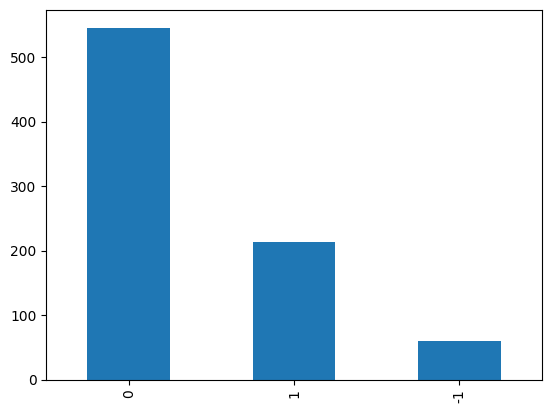

In [ ]:
sentence_df['VADer'] = sentence_df['VADer'].apply(valuemaker)
sentence_df.VADer.value_counts().plot.bar()

In [ ]:
sentence_df.iloc[412,2]

-1

In [ ]:
sentence_df.iloc[412,1]

'It will not shy away from mentioning the abuse of Uyghurs.'

In [ ]:
# Preprocess text (username and link placeholders)
def preprocess(text):
    new_text = []
    for t in str(text).split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

# Preprocess the text in your DataFrame
sentence_df['preprocessed_text'] = sentence_df['sentences'].apply(preprocess)

In [ ]:
 # Load the pre-trained model and tokenizer
task = 'sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Download label mapping
labels = []
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
    labels = [row[1] for row in csvreader if len(row) > 1]

# Specify the number of rows to process
num_rows = 818

# Create a subset of the DataFrame with the desired number of rows
df_subset = sentence_df.head(num_rows)

# Perform sentiment analysis on each preprocessed text
bert_sentiments = []
for text in sentence_df['preprocessed_text'].head(num_rows):
    encoded_input = tokenizer(text, truncation=True, padding=True, max_length=128, return_tensors='pt')
    output = model(**encoded_input)
    scores = output.logits[0].detach().numpy()
    scores = softmax(scores)
    ranking = np.argsort(scores)
    ranking = ranking[::-1]
    sentiment_label = labels[ranking[0]]  # Assuming you want to retrieve the top-ranked sentiment label
    bert_sentiments.append(sentiment_label)

# Assign the generated sentiments to a new column in your DataFrame
sentence_df['BERT'] = bert_sentiments

# Print the DataFrame with the generated sentiments
#print(df_subset[['sentences', 'Scores', 'generated_sentiment']])

In [ ]:
# Count unique values in a column
unique_VADer = sentence_df['VADer'].value_counts()
unique_BERT = sentence_df['BERT'].value_counts()

# Print the unique values and their counts
print(unique_VADer,unique_BERT)

 0    546
 1    213
-1     59
Name: VADer, dtype: int64 neutral     448
positive    286
negative     84
Name: BERT, dtype: int64
